# Customer Lifetime Value (LTV) Modeling

This notebook estimates customer value using revenue-related features and prepares LTV insights to combine with churn prediction results.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_data.csv")
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleLines_Y

In [4]:
df.shape

(7032, 31)

In [5]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [6]:
# Create basic ltv column
# LTV = MonthlyCharges × tenure
df["Estimated_LTV"] = df["MonthlyCharges"] * df["tenure"]

In [7]:
df[["tenure", "MonthlyCharges", "TotalCharges", "Estimated_LTV"]].head()

,tenure,MonthlyCharges,TotalCharges,Estimated_LTV
0,1,29.85,29.85,29.85
1,34,56.95,1889.50,1936.30
2,2,53.85,108.15,107.70
3,45,42.30,1840.75,1903.50
4,2,70.70,151.65,141.40


### Observation

Estimated LTV was calculated using MonthlyCharges and tenure to represent the approximate revenue generated by each customer during their subscription period.

In [8]:
# LTV distribution
df["Estimated_LTV"].describe()

count    7032.000000
mean     2283.147248
std      2264.703327
min        18.800000
25%       397.800000
50%      1394.575000
75%      3791.250000
max      8550.000000
Name: Estimated_LTV, dtype: float64

### Observation

The Estimated LTV distribution shows significant variation across customers. The average Estimated LTV is approximately 2283, while the median is approximately 1395, indicating that a smaller group of high-value customers increases the overall average. The 25th percentile (397.8), 50th percentile (1394.58), and 75th percentile (3791.25) values will be used to create customer value segments for business analysis and retention planning.

In [9]:
#Ltv segments
def ltv_segment(ltv):
    if ltv < 1394.575:
        return "Low Value"
    elif ltv < 3791.25:
        return "Medium Value"
    else:
        return "High Value"

df["LTV_Segment"] = df["Estimated_LTV"].apply(ltv_segment)

In [11]:
df[["Estimated_LTV", "LTV_Segment"]].head(-10)

,Estimated_LTV,LTV_Segment
0,29.85,Low Value
1,1936.30,Medium Value
2,107.70,Low Value
3,1903.50,Medium Value
4,141.40,Low Value
...,...,...
7017,4358.80,High Value
7018,266.40,Low Value
7019,40.10,Low Value
7020,3300.00,Medium Value


In [12]:
# customer count in each segment
df["LTV_Segment"].value_counts()

LTV_Segment
Low Value       3516
Medium Value    1758
High Value      1758
Name: count, dtype: int64

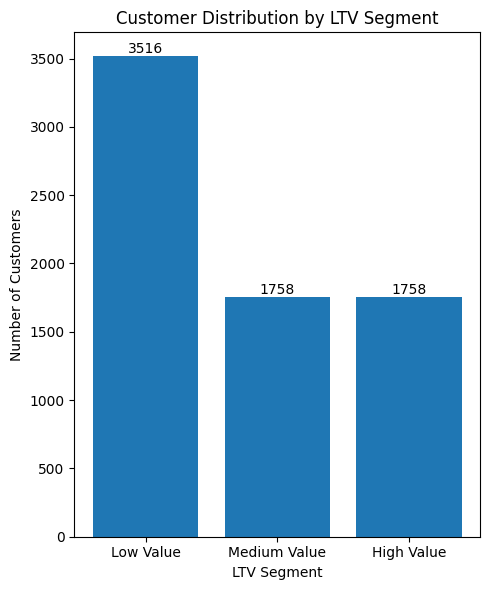

In [17]:
import matplotlib.pyplot as plt

segment_counts = df["LTV_Segment"].value_counts()

plt.figure(figsize=(5,6))
bars = plt.bar(segment_counts.index, segment_counts.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Customer Distribution by LTV Segment")
plt.xlabel("LTV Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Observation

The LTV segmentation chart shows that 3,516 customers belong to the Low Value segment, while 1,758 customers each belong to the Medium Value and High Value segments. The High Value customers contribute the greatest business value and should be prioritized when combined with churn predictions to develop customer retention strategies.

In [19]:
# Churn Distribution by LTV Segment
pd.crosstab(df["LTV_Segment"], df["Churn"])

Churn,0,1
LTV_Segment,,
High Value,1504,254
Low Value,2306,1210
Medium Value,1353,405


In [21]:
pd.crosstab(
    df["LTV_Segment"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,0,1
LTV_Segment,,
High Value,85.55,14.45
Low Value,65.59,34.41
Medium Value,76.96,23.04


### Observation

Churn behaviour differs across customer value segments. The Low Value segment has the highest churn rate (34.41%), followed by the Medium Value segment (23.04%). The High Value segment shows the lowest churn rate (14.45%), indicating that high-value customers are generally more loyal and have a lower tendency to leave the service.

*This analysis demonstrates that customer value and churn behaviour are related and can be combined to identify business priorities for retention campaigns.*